<a href="https://colab.research.google.com/github/sainiveditha04/FUTURE_ML_03/blob/main/resume_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resume Screening & Ranking System

This notebook builds an end-to-end pipeline that:

1. Classifies resumes into job categories using NLP + machine learning
2. Scores each resume against a specific job description's required skills
3. Ranks candidates by match score and reports their missing skills

**Dataset:** Resume Screening Dataset (Kaggle) — 962 resumes across 25 job categories.

## 1. Load the Dataset

Pulling the CSV directly from the GitHub repo via its raw URL — no manual upload, no local path issues. This also means the notebook runs identically for anyone who opens it, including a recruiter clicking "Run All" in Colab.

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/sainiveditha04/FUTURE_ML_03/main/Resume%20Screening.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (962, 2)


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


## 2. Explore the Data

Quick sanity check on the categories we're classifying into.

In [3]:
print("Categories:")
print(df['Category'].unique())

print("\nNumber of Categories:", df['Category'].nunique())

Categories:
['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']

Number of Categories: 25


### Category Distribution

Visualizing class balance matters here — if some categories have far fewer resumes than others, the classifier will be biased toward the majority categories.

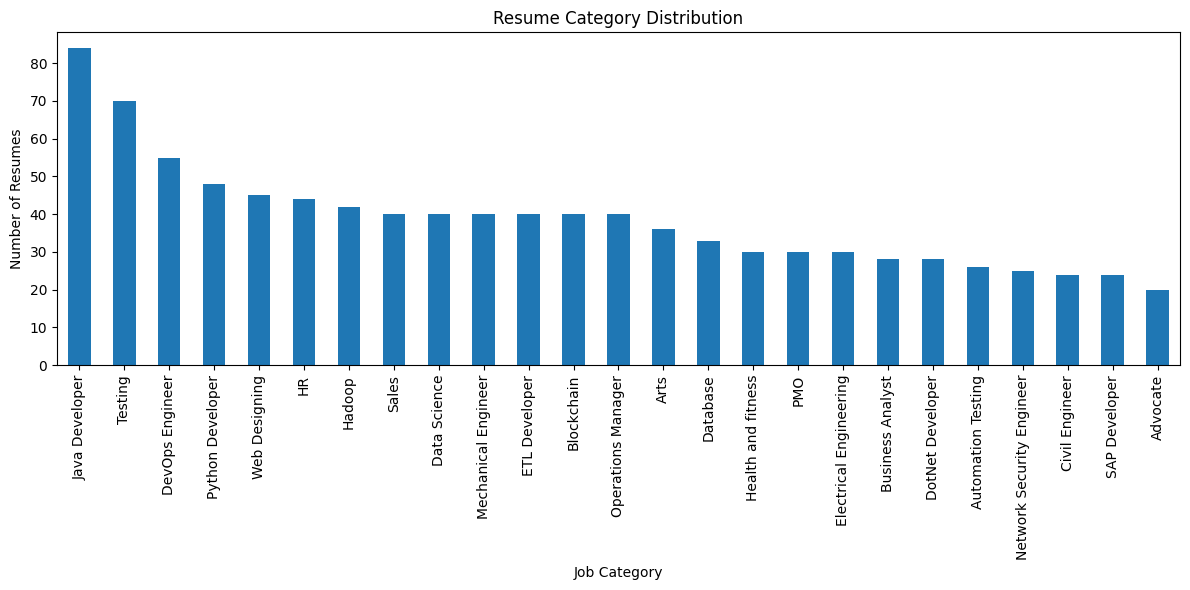

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df['Category'].value_counts().plot(kind='bar')

plt.title("Resume Category Distribution")
plt.xlabel("Job Category")
plt.ylabel("Number of Resumes")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 3. Text Cleaning

Raw resume text contains URLs, email handles, and punctuation that add noise to the TF-IDF vocabulary without adding signal. `clean_resume()` strips those out and lowercases everything so that "Python" and "python" aren't treated as different tokens.

In [5]:
import re

def clean_resume(text):
    text = re.sub(r'http\S+', ' ', text)          # remove URLs
    text = re.sub(r'www\S+', ' ', text)           # remove websites
    text = re.sub(r'@\S+', ' ', text)             # remove mentions
    text = re.sub(r'[^a-zA-Z ]', ' ', text)       # keep only letters
    text = re.sub(r'\s+', ' ', text)              # remove extra spaces
    return text.lower().strip()

df['Cleaned_Resume'] = df['Resume'].apply(clean_resume)

print(df[['Category', 'Cleaned_Resume']].head())

       Category                                     Cleaned_Resume
0  Data Science  skills programming languages python pandas num...
1  Data Science  education details may to may b e uit rgpv data...
2  Data Science  areas of interest deep learning control system...
3  Data Science  skills r python sap hana tableau sap hana sql ...
4  Data Science  education details mca ymcaust faridabad haryan...


## 4. Encode Labels

Scikit-learn's classifiers need numeric targets, so each category string is mapped to an integer ID.

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Category_Encoded'] = le.fit_transform(df['Category'])

print(df[['Category', 'Category_Encoded']].head())

       Category  Category_Encoded
0  Data Science                 6
1  Data Science                 6
2  Data Science                 6
3  Data Science                 6
4  Data Science                 6


## 5. TF-IDF Feature Extraction

We convert cleaned resume text into a 5,000-dimension TF-IDF matrix. TF-IDF weighs words by how distinctive they are to a document relative to the whole corpus — so common resume filler ("experience", "team") gets down-weighted while role-specific terms stand out.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = tfidf.fit_transform(df['Cleaned_Resume'])

y = df['Category_Encoded']

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (962, 5000)


## 6. Train/Test Split

80/20 split, fixed `random_state` for reproducibility.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (769, 5000)
Test Shape: (193, 5000)


## 7. Train Classification Models

Two models are trained for comparison:

- **Logistic Regression** — a strong linear baseline for high-dimensional sparse text features
- **Multinomial Naive Bayes** — fast, and a classic choice for TF-IDF/bag-of-words text classification

Whichever scores higher on the held-out test set is the one used later for the live category prediction demo.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9948186528497409


In [10]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9896373056994818


### A note on the accuracy numbers

Both models score above 98% here. On a 25-class text classification problem, accuracy this high is usually a signal that the dataset contains many near-duplicate resumes within each category (common in this particular Kaggle dataset) rather than evidence the model would generalize this well on unseen, real-world resumes. Worth stating explicitly rather than presenting the number at face value — it shows you understand *why* the result looks the way it does, not just what it is.

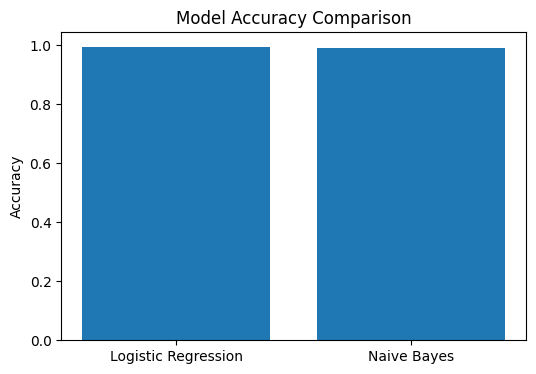

Logistic Regression: 0.9948186528497409
Naive Bayes: 0.9896373056994818


In [11]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Naive Bayes"]
scores = [lr_accuracy, nb_accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

print("Logistic Regression:", lr_accuracy)
print("Naive Bayes:", nb_accuracy)

### Quick Category Prediction Demo

A sanity check: feed the trained model a short skills snippet and confirm it predicts a sensible category.

In [12]:
sample_resume = """
Python
Machine Learning
Deep Learning
Pandas
NumPy
SQL
Data Analysis
"""

sample_vector = tfidf.transform([clean_resume(sample_resume)])

prediction = lr_model.predict(sample_vector)

predicted_category = le.inverse_transform(prediction)

print("Predicted Category:", predicted_category[0])

Predicted Category: Data Science


## 8. Resume-to-Job Matching & Scoring

The classification model above answers *"what category is this resume?"* — useful, but a recruiter's real question is *"how well does this specific candidate fit this specific job?"*

This section implements that: define a job description, extract its required skills, then score every resume in the dataset by what fraction of those required skills it mentions.

In [13]:
job_description = """
Looking for a Data Scientist with skills in:
Python, Machine Learning, Deep Learning,
SQL, Pandas, NumPy, Data Visualization,
Statistics and Data Analysis.
"""

print(job_description)


Looking for a Data Scientist with skills in:
Python, Machine Learning, Deep Learning,
SQL, Pandas, NumPy, Data Visualization,
Statistics and Data Analysis.



In [14]:
required_skills = [
    "python",
    "machine learning",
    "deep learning",
    "sql",
    "pandas",
    "numpy",
    "statistics",
    "data analysis",
    "data visualization"
]

print(required_skills)

['python', 'machine learning', 'deep learning', 'sql', 'pandas', 'numpy', 'statistics', 'data analysis', 'data visualization']



### How the Match Score is Calculated

`calculate_match_score()` lowercases the resume text and checks, skill by skill, whether each required skill keyword appears anywhere in it. The match score is simply: score = (number of required skills found) / (total required skills) × 100

This is a **keyword-presence score**, not a semantic similarity score — it's intentionally simple and explainable: a recruiter can see *exactly* why a candidate scored what they scored, rather than trusting a black-box embedding distance. The trade-off is that it won't catch synonyms (e.g. "NLP" vs. "Natural Language Processing") — a good next iteration would be to expand each required skill into a list of accepted aliases

In [16]:
def calculate_match_score(resume_text):

    resume_text = str(resume_text).lower()

    matched = []

    for skill in required_skills:
        if skill in resume_text:
            matched.append(skill)

    score = (len(matched) / len(required_skills)) * 100

    return score, matched

### Apply Scoring to Every Candidate

In [17]:
scores = []
matched_skills = []

for resume in df['Resume']:

    score, skills = calculate_match_score(resume)

    scores.append(score)
    matched_skills.append(skills)

df['Match_Score'] = scores
df['Matched_Skills'] = matched_skills

df[['Category','Match_Score']].head()

,Category,Match_Score
0,Data Science,66.666667
1,Data Science,22.222222
2,Data Science,55.555556
3,Data Science,44.444444
4,Data Science,22.222222


## 9. Identify Missing Skills

For every candidate, `missing_skills()` takes the set difference between the full required-skills list and what was actually matched — this is the part a recruiter cares about most: *what's the gap?* This runs **before** ranking so the ranked table already carries the missing-skills column.

In [18]:
def missing_skills(matched):

    return list(
        set(required_skills) -
        set(matched)
    )

df['Missing_Skills'] = df[
    'Matched_Skills'
].apply(missing_skills)

df[
    ['Match_Score',
     'Matched_Skills',
     'Missing_Skills']
].head()

,Match_Score,Matched_Skills,Missing_Skills
0,66.666667,"[python, machine learning, deep learning, sql,...","[data visualization, data analysis, statistics]"
1,22.222222,"[python, machine learning]","[pandas, statistics, numpy, sql, data visualiz..."
2,55.555556,"[python, machine learning, deep learning, sql,...","[pandas, statistics, numpy, data visualization]"
3,44.444444,"[python, machine learning, deep learning, sql]","[pandas, statistics, numpy, data visualization..."
4,22.222222,"[python, data analysis]","[pandas, statistics, numpy, sql, data visualiz..."


## 10. Rank Candidates

Sorting by `Match_Score` descending answers *"why does this candidate rank higher than that one?"* — directly: they simply mention more of the required skills. Because the score is built from explicit keyword matches (see Section 8), the ranking is fully auditable — you can always trace a rank back to the exact skills that drove it.

In [19]:
ranked_candidates = df.sort_values(
    by="Match_Score",
    ascending=False
)

ranked_candidates[
    ['Category','Match_Score','Missing_Skills']
].head(10)

,Category,Match_Score,Missing_Skills
30,Data Science,66.666667,"[data visualization, data analysis, statistics]"
27,Data Science,66.666667,"[data visualization, data analysis, statistics]"
28,Data Science,66.666667,"[data visualization, data analysis, statistics]"
17,Data Science,66.666667,"[data visualization, data analysis, statistics]"
38,Data Science,66.666667,"[data visualization, data analysis, statistics]"
37,Data Science,66.666667,"[data visualization, data analysis, statistics]"
20,Data Science,66.666667,"[data visualization, data analysis, statistics]"
18,Data Science,66.666667,"[data visualization, data analysis, statistics]"
7,Data Science,66.666667,"[data visualization, data analysis, statistics]"
8,Data Science,66.666667,"[data visualization, data analysis, statistics]"


### Top Candidate Summary

In [20]:
top_candidate = ranked_candidates.iloc[0]

print("TOP CANDIDATE SCORE:")
print(top_candidate['Match_Score'])

print("\nMATCHED SKILLS:")
print(top_candidate['Matched_Skills'])

print("\nMISSING SKILLS:")
print(top_candidate['Missing_Skills'])

TOP CANDIDATE SCORE:
66.66666666666666

MATCHED SKILLS:
['python', 'machine learning', 'deep learning', 'sql', 'pandas', 'numpy']

MISSING SKILLS:
['data visualization', 'data analysis', 'statistics']


## 11. Visualize the Top 10 Candidates

A quick bar chart turns the ranking table into something glanceable for a non-technical reviewer.

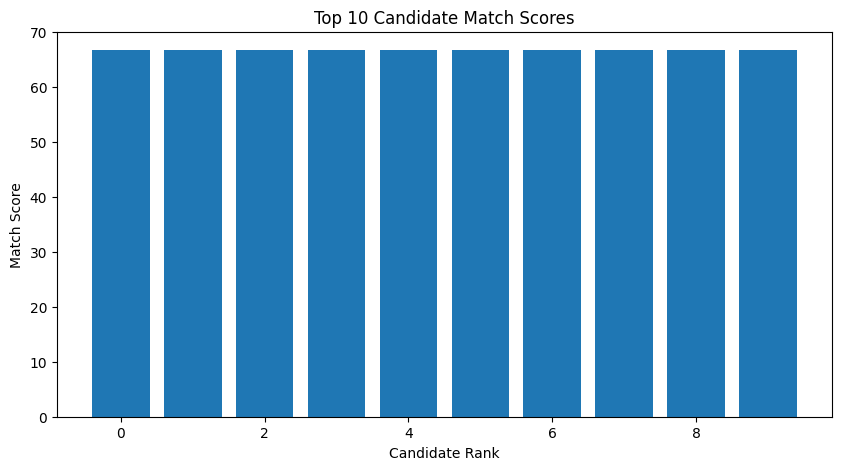

In [21]:
import matplotlib.pyplot as plt

top10 = ranked_candidates.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top10)),
    top10['Match_Score']
)

plt.title("Top 10 Candidate Match Scores")
plt.xlabel("Candidate Rank")
plt.ylabel("Match Score")

plt.show()

## Summary

- **Classification** sorts resumes into job categories with >98% test accuracy, though that number should be read alongside the duplicate-resume caveat above.
- **Scoring** is a transparent, keyword-based match against a specific job description — every score is traceable back to which required skills were found or missing.
- **Ranking** follows directly from that score, so the "why does X outrank Y" question always has a concrete, inspectable answer.
- **Next steps** for a production version: synonym/alias handling for skills, weighting skills by importance rather than treating them all equally, and testing against resumes outside this specific Kaggle dataset to check the accuracy holds up on real-world data.